# LAB 01B — Crossing UTM Zones in Spatial Analysis

## Executive summary

Projected coordinate systems provide Cartesian coordinates in metric units, but coordinates from different projected Coordinate Reference Systems (CRSs) are not automatically comparable.

This laboratory demonstrates a common spatial-analysis failure mode using two synthetic mineral-exploration locations positioned on opposite sides of the boundary between UTM Zones 18S and 19S in Chile.

Three approaches are compared:

1. an independent geodesic distance on the WGS84 ellipsoid;
2. both observations transformed to one common projected CRS;
3. an intentionally incorrect calculation using coordinates independently projected into different UTM zones.

The objective is to demonstrate why a spatial project requires a consistent analysis CRS rather than independently selecting a projection for each feature.

> **Key idea:** metric units alone do not guarantee spatial comparability.

## 1. Problem

A regional mineral-exploration study may contain observations located across more than one UTM zone.

Near longitude **-72°**, observations immediately west and east of the boundary may belong to different projected Coordinate Reference Systems:

- west of the boundary: **UTM Zone 18S — EPSG:32718**;
- east of the boundary: **UTM Zone 19S — EPSG:32719**.

Each projection may be locally appropriate for its own location.

However, their Easting and Northing coordinates do not belong to the same Cartesian reference frame.

Directly comparing those coordinate values can therefore produce a numerical result that is computationally valid but spatially invalid.

## 2. Mineral-exploration relevance

Regional exploration workflows commonly integrate spatial evidence such as:

- geological faults;
- lithological contacts;
- intrusive bodies;
- mineral occurrences;
- geochemical anomalies;
- drilling locations;
- geophysical observations;
- raster-derived predictors.

Many GeoAI features are derived from spatial relationships, including:

- distance to fault;
- distance to intrusive body;
- nearest mineral occurrence;
- neighbourhood density;
- buffer membership;
- spatial intersection;
- proximity to geochemical anomalies.

If geometries from incompatible CRSs are combined without harmonization, these derived variables may become incorrect even though the software executes successfully.

This type of silent spatial error can later propagate into machine-learning models.

## 3. Analytical strategy

The experiment compares three approaches.

### Reference approach

Calculate the geodesic distance directly on the WGS84 ellipsoid.

### Valid projected approach

Transform both observations into one common projected CRS before calculating their planar distance.

### Intentionally invalid approach

Project each observation independently into its local UTM zone and then subtract the resulting X/Y coordinates as if they belonged to the same Cartesian plane.

The third approach is included deliberately to demonstrate why CRS metadata and project-level spatial consistency matter.

In [1]:
from __future__ import annotations

from math import hypot

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

from pyproj import Geod
from shapely.geometry import Point

from geoai.crs import (
    utm_zone_from_longitude,
    wgs84_utm_epsg,
)

## 4. Synthetic cross-zone scenario

Two synthetic observations are positioned at the same latitude and on opposite sides of the longitude boundary between UTM Zones 18 and 19.

Synthetic coordinates are used intentionally to isolate the CRS problem without introducing private, licensed, or externally dependent exploration data.

In [2]:
locations = gpd.GeoDataFrame(
    {
        "site": ["SITE_A", "SITE_B"],
    },
    geometry=[
        Point(-72.2, -30.0),
        Point(-71.8, -30.0),
    ],
    crs="EPSG:4326",
)

display(locations)

print()
print("Coordinate Reference System")
print("---------------------------")
print(f"CRS       : {locations.crs}")
print(f"EPSG code : {locations.crs.to_epsg()}")
print("Units     : degrees")

,site,geometry
0,SITE_A,POINT (-72.2 -30)
1,SITE_B,POINT (-71.8 -30)



Coordinate Reference System
---------------------------
CRS       : EPSG:4326
EPSG code : 4326
Units     : degrees


### Scenario interpretation

Both observations are currently represented in **WGS 84 / EPSG:4326**.

Their coordinates are longitude and latitude expressed in degrees.

At this stage, no metric distance calculation has been performed.

## 5. Individual UTM zone identification

Before performing any projected calculation, we inspect which UTM zone corresponds to each observation individually.

This is a **diagnostic step**.

It does not imply that each feature should later be projected independently when they participate in the same spatial operation.

In [3]:
utm_records = []

for _, row in locations.iterrows():
    lon = row.geometry.x
    lat = row.geometry.y

    zone = utm_zone_from_longitude(lon)
    epsg = wgs84_utm_epsg(lon, lat)

    utm_records.append(
        {
            "site": row["site"],
            "longitude": lon,
            "latitude": lat,
            "utm_zone": zone,
            "epsg": epsg,
        }
    )

utm_table = pd.DataFrame(utm_records)

display(utm_table)

,site,longitude,latitude,utm_zone,epsg
0,SITE_A,-72.2,-30.0,18,32718
1,SITE_B,-71.8,-30.0,19,32719


In [4]:
for record in utm_records:
    print(
        f"{record['site']}: "
        f"lon={record['longitude']:.1f}, "
        f"lat={record['latitude']:.1f}, "
        f"UTM zone={record['utm_zone']}, "
        f"EPSG={record['epsg']}"
    )

SITE_A: lon=-72.2, lat=-30.0, UTM zone=18, EPSG=32718
SITE_B: lon=-71.8, lat=-30.0, UTM zone=19, EPSG=32719


### Finding

Both observations have valid local UTM assignments:

| Site | Longitude | UTM zone | CRS |
| --- | ---: | ---: | --- |
| SITE_A | -72.2° | 18S | EPSG:32718 |
| SITE_B | -71.8° | 19S | EPSG:32719 |

Both CRSs use metres.

However, they do **not** use the same projected coordinate system.

> **Same units do not imply the same coordinate space.**

## 6. Independent geodesic reference

Before testing projected approaches, we establish an independent reference distance using the WGS84 ellipsoid.

A geodesic calculation measures the shortest path over the ellipsoidal representation of the Earth and does not require both locations to belong to the same projected CRS.

This value will be used as the reference against which the projected calculations are compared.

In [5]:
geod = Geod(ellps="WGS84")

point_a = locations.geometry.iloc[0]
point_b = locations.geometry.iloc[1]

forward_azimuth, back_azimuth, geodesic_distance_m = geod.inv(
    point_a.x,
    point_a.y,
    point_b.x,
    point_b.y,
)

print(f"Geodesic distance : {geodesic_distance_m:,.2f} m")
print(f"Geodesic distance : {geodesic_distance_m / 1000:,.3f} km")
print(f"Forward azimuth   : {forward_azimuth:.2f}°")

Geodesic distance : 38,594.49 m
Geodesic distance : 38.594 km
Forward azimuth   : 90.10°


### Reference result

The two synthetic observations are approximately **38.6 km apart** according to the WGS84 geodesic calculation.

This value provides an independent reference before any projected coordinate system is introduced.

## 7. The dangerous approach — mixing projected coordinate systems

A tempting workflow is to project every observation into the UTM zone that best matches its individual longitude.

For these observations:

- SITE_A is projected to EPSG:32718;
- SITE_B is projected to EPSG:32719.

Each transformation is individually valid.

The error occurs when the resulting Easting/Northing values are subsequently treated as coordinates belonging to one shared Cartesian system.

The following calculation is **intentionally incorrect** and exists only to demonstrate the failure mode.

In [6]:
site_a_utm18 = locations.iloc[[0]].to_crs(epsg=32718)
site_b_utm19 = locations.iloc[[1]].to_crs(epsg=32719)

point_a_utm18 = site_a_utm18.geometry.iloc[0]
point_b_utm19 = site_b_utm19.geometry.iloc[0]

print("SITE_A — EPSG:32718")
print(
    f"Easting={point_a_utm18.x:,.2f} m, "
    f"Northing={point_a_utm18.y:,.2f} m"
)

print()

print("SITE_B — EPSG:32719")
print(
    f"Easting={point_b_utm19.x:,.2f} m, "
    f"Northing={point_b_utm19.y:,.2f} m"
)

SITE_A — EPSG:32718
Easting=770,107.67 m, Northing=6,677,913.00 m

SITE_B — EPSG:32719
Easting=229,892.33 m, Northing=6,677,913.00 m


In [7]:
wrong_distance_m = hypot(
    point_b_utm19.x - point_a_utm18.x,
    point_b_utm19.y - point_a_utm18.y,
)

wrong_relative_difference_pct = (
    abs(wrong_distance_m - geodesic_distance_m)
    / geodesic_distance_m
    * 100
)

print(f"INVALID mixed-CRS distance : {wrong_distance_m:,.2f} m")
print(f"INVALID mixed-CRS distance : {wrong_distance_m / 1000:,.3f} km")
print(
    "Difference vs geodesic    : "
    f"{wrong_relative_difference_pct:,.2f}%"
)

INVALID mixed-CRS distance : 540,215.33 m
INVALID mixed-CRS distance : 540.215 km
Difference vs geodesic    : 1,299.72%


### Failure demonstrated

The actual geodesic separation is approximately:

**38.6 km**

The invalid mixed-CRS calculation produces approximately:

**540.2 km**

The software still returns a perfectly valid floating-point number.

No exception is required.

The failure is therefore **semantic and geospatial**, rather than computational.

The Easting values cannot be directly compared because EPSG:32718 and EPSG:32719 use different projected reference frames.

> A successful calculation does not guarantee a valid spatial measurement.

## 8. Correct approach — use one common analysis CRS

For a joint projected spatial operation, all participating geometries must first be represented in one compatible analysis CRS.

For this small synthetic study area, **WGS 84 / UTM Zone 19S (EPSG:32719)** is selected as a common projected CRS for demonstration.

The important decision is not that every feature has its own locally optimal UTM zone.

The important decision is that the **analysis uses one documented and consistent spatial reference system**.

In a real exploration project, CRS selection should additionally consider study-area extent, distortion, official geological datasets, raster alignment, and organizational standards.

In [8]:
COMMON_EPSG = 32719

locations_common = locations.to_crs(epsg=COMMON_EPSG)

display(locations_common)

print()
print(f"Common analysis CRS: EPSG:{COMMON_EPSG}")
print(f"CRS name           : {locations_common.crs.name}")

,site,geometry
0,SITE_A,POINT (191286.584 6676901.362)
1,SITE_B,POINT (229892.334 6677912.999)



Common analysis CRS: EPSG:32719
CRS name           : WGS 84 / UTM zone 19S


In [9]:
common_distance_m = (
    locations_common.geometry.iloc[0].distance(
        locations_common.geometry.iloc[1]
    )
)

common_absolute_difference_m = abs(
    common_distance_m - geodesic_distance_m
)

common_relative_difference_pct = (
    common_absolute_difference_m
    / geodesic_distance_m
    * 100
)

print(f"Common-CRS distance       : {common_distance_m:,.2f} m")
print(f"Geodesic reference        : {geodesic_distance_m:,.2f} m")
print(
    f"Absolute difference       : "
    f"{common_absolute_difference_m:,.2f} m"
)
print(
    f"Relative difference       : "
    f"{common_relative_difference_pct:.4f}%"
)

Common-CRS distance       : 38,619.00 m
Geodesic reference        : 38,594.49 m
Absolute difference       : 24.51 m
Relative difference       : 0.0635%


### Correct projected result

Transforming both observations into one common projected CRS produces a distance of approximately **38.62 km**.

The result differs from the WGS84 geodesic reference by only about **0.06%** in this local example.

The small difference is consistent with the fact that a projected CRS represents the curved Earth on a plane and therefore introduces some distortion.

The essential improvement is that both observations now belong to the **same coordinate system** before the planar distance calculation is performed.

## 9. Results comparison

The three approaches can now be compared directly.

In [10]:
results = pd.DataFrame(
    {
        "method": [
            "WGS84 geodesic reference",
            "Common CRS — EPSG:32719",
            "INVALID — mixed UTM 18S / 19S",
        ],
        "distance_m": [
            geodesic_distance_m,
            common_distance_m,
            wrong_distance_m,
        ],
        "spatially_valid": [
            True,
            True,
            False,
        ],
    }
)

results["distance_km"] = results["distance_m"] / 1000

results["difference_vs_geodesic_m"] = (
    results["distance_m"] - geodesic_distance_m
).abs()

results["relative_difference_pct"] = (
    results["difference_vs_geodesic_m"]
    / geodesic_distance_m
    * 100
)

display(
    results.round(
        {
            "distance_m": 2,
            "distance_km": 3,
            "difference_vs_geodesic_m": 2,
            "relative_difference_pct": 4,
        }
    )
)

,method,distance_m,spatially_valid,distance_km,difference_vs_geodesic_m,relative_difference_pct
0,WGS84 geodesic reference,38594.49,True,38.594,0.00,0.0000
1,Common CRS — EPSG:32719,38619.00,True,38.619,24.51,0.0635
2,INVALID — mixed UTM 18S / 19S,540215.33,False,540.215,501620.84,1299.7213


## 10. Programmatic validation

The synthetic experiment is deterministic, so simple assertions can be used to protect the expected behaviour.

These checks turn the conceptual lesson into executable evidence.

In [11]:
assert utm_zone_from_longitude(-72.2) == 18
assert utm_zone_from_longitude(-71.8) == 19

assert wgs84_utm_epsg(-72.2, -30.0) == 32718
assert wgs84_utm_epsg(-71.8, -30.0) == 32719

assert common_relative_difference_pct < 0.1
assert wrong_relative_difference_pct > 1000

print("Validation checks: PASS")

Validation checks: PASS


## 11. Visual evidence — UTM zone boundary

The first visualization shows the observations in geographic coordinates and the approximate longitudinal boundary separating UTM Zones 18 and 19 in this example.

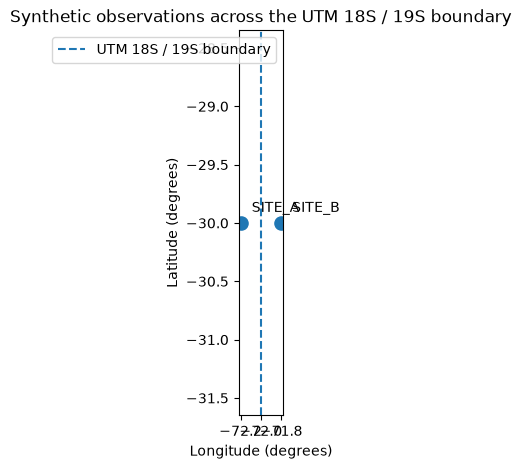

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

locations.plot(
    ax=ax,
    marker="o",
    markersize=90,
)

ax.axvline(
    x=-72.0,
    linestyle="--",
    label="UTM 18S / 19S boundary",
)

for _, row in locations.iterrows():
    ax.annotate(
        row["site"],
        (row.geometry.x, row.geometry.y),
        xytext=(8, 8),
        textcoords="offset points",
    )

ax.set_title(
    "Synthetic observations across the UTM 18S / 19S boundary"
)
ax.set_xlabel("Longitude (degrees)")
ax.set_ylabel("Latitude (degrees)")
ax.legend()

plt.show()

## 12. Visual evidence — impact of the CRS error

The following comparison makes the magnitude of the mixed-CRS error directly visible.

The objective is not to compare modelling performance, but to show how a CRS inconsistency can radically alter a derived spatial feature.

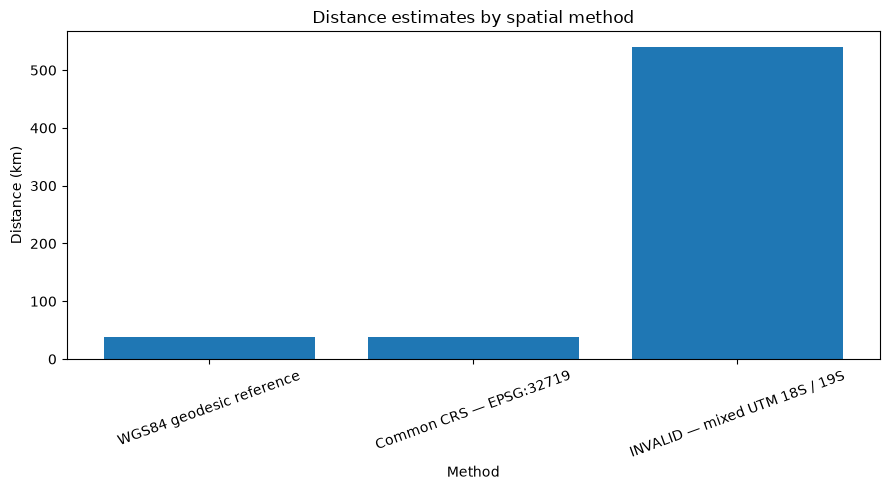

In [13]:
distance_plot = results.copy()

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    distance_plot["method"],
    distance_plot["distance_km"],
)

ax.set_title("Distance estimates by spatial method")
ax.set_ylabel("Distance (km)")
ax.set_xlabel("Method")
ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 13. Interpretation

This experiment demonstrates three different concepts.

### 1. A local CRS may be valid without being mutually compatible

EPSG:32718 is appropriate for SITE_A and EPSG:32719 is appropriate for SITE_B when each location is considered independently.

That does not make their projected coordinates directly comparable.

### 2. Units are necessary but not sufficient

Both UTM systems express coordinates in metres.

Nevertheless, their Easting and Northing values belong to different projected reference frames.

### 3. Spatial operations require a project-level CRS decision

When multiple geometries participate in the same planar operation, they must first be represented in a compatible common CRS.

This is a project-level analytical decision rather than a per-feature decision.

## 14. GeoAI implications

CRS inconsistencies can contaminate spatial features before they reach a machine-learning model.

Examples include:

`distance_to_fault_m`

`distance_to_intrusive_m`

`distance_to_contact_m`

`distance_to_occurrence_m`

`nearest_anomaly_distance_m`

`neighbourhood_density`

A model may still train successfully on these features.

The resulting predictions, metrics, and explainability outputs may therefore appear technically valid while being based on spatially corrupted inputs.

For GeoAI, spatial validation must occur **before** predictive modelling.

## 15. Engineering controls

Several controls reduce the risk demonstrated in this laboratory:

1. preserve CRS metadata throughout the spatial pipeline;
2. validate CRS compatibility before joint spatial operations;
3. define an explicit project analysis CRS;
4. avoid converting geometries to raw X/Y arrays before CRS validation;
5. document spatial units;
6. compare selected projected measurements against an independent geodesic reference when appropriate;
7. add automated tests for reusable CRS logic.

The existing project utilities under:

`src/geoai/crs.py`

support UTM-zone and EPSG identification.

Reusable CRS logic is covered by automated tests under:

`tests/test_crs.py`

## 16. Limitations

This laboratory uses a deliberately small synthetic example to isolate one CRS failure mode.

It does not imply that UTM Zone 19S is universally appropriate for projects spanning multiple zones.

Real project CRS selection should consider:

- geographic extent;
- projection distortion;
- official geological and cartographic standards;
- raster CRS and resolution;
- interoperability with external datasets;
- area, distance, or direction preservation requirements;
- project and organizational conventions.

Large regional, national, or continental analyses may require alternatives to using a single local UTM zone.

## Key takeaway

> **Same units do not mean same coordinate system.**

A spatial workflow can produce a valid number while performing an invalid geographical comparison.

For joint projected operations:

**identify CRS → harmonize CRS → validate units → calculate → independently verify → interpret**

LAB 01B therefore extends LAB 01A from:

**“degrees are not metres”**

to the more general principle:

**“metric coordinates are not automatically comparable unless they share a compatible spatial reference system.”**